# CesarLenKey — Shift Function Analysis

**Goal:** Analyse the pseudo-randomness and quality of the shift calculation function
used in `CryptedWord()`. We examine how the shift depends on word length and key length,
check for collisions, dead zones, periodicities, and singularities.

### The function under analysis

```python
coef = abs(len(key) * sin(len(word) * len(key))) + len(key)

shift = abs(round(
    (coef ** 2)
    * (cos(len(word) / len(key) - 1) / sin(len(key) / len(word) + 1))
    * (sin(len(word) / len(key) + 1) / cos(len(key) / len(word) - 1))
))
```

Let $w = len(word)$, $k = len(key)$, both positive integers. Then:

$$C(w,k) = |k \cdot \sin(w \cdot k)| + k$$
$$S(w,k) = \left| \mathrm{round}\left( C^2 \cdot \frac{\cos(w/k - 1)}{\sin(k/w + 1)} \cdot \frac{\sin(w/k + 1)}{\cos(k/w - 1)} \right) \right|$$


In [52]:
from collections import Counter
from math import cos, sin

import matplotlib.pyplot as plt
import numpy as np


plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11

In [53]:
def compute_shift(word_len: int, key_len: int) -> int:
  coef = abs(key_len * sin(word_len * key_len)) + key_len
  shift = abs(
    round(
      (coef**2)
      * (cos(word_len / key_len - 1) / sin(key_len / word_len + 1))
      * (sin(word_len / key_len + 1) / cos(key_len / word_len - 1))
    )
  )
  return shift

## 1. Single-Variable Sweep

Fix one variable and sweep the other. Observe linear vs. oscillatory behaviour.


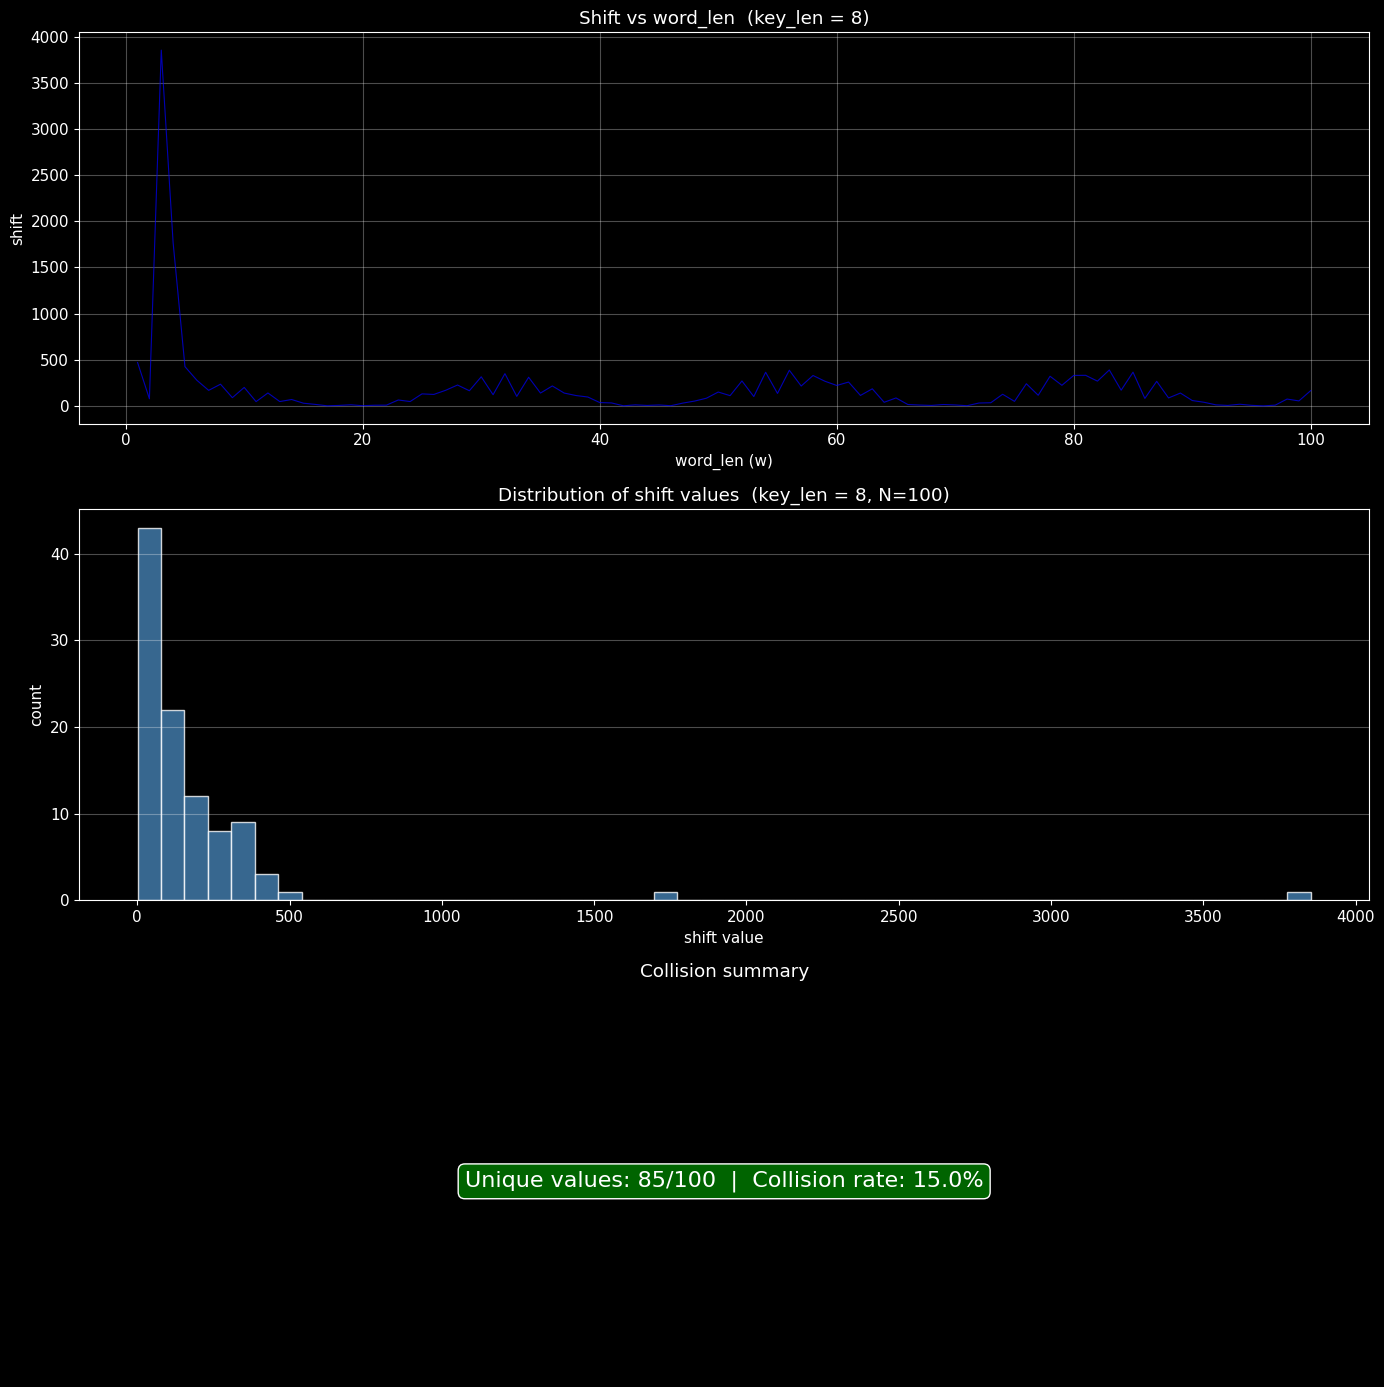

In [54]:
k_fixed = 8
w_range = np.arange(1, 101)
shifts_w = [compute_shift(int(w), k_fixed) for w in w_range]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))

ax1.plot(w_range, shifts_w, "b-", alpha=0.7, linewidth=0.8)
ax1.set_xlabel("word_len (w)")
ax1.set_ylabel("shift")
ax1.set_title(f"Shift vs word_len  (key_len = {k_fixed})")
ax1.grid(True, alpha=0.3)

ax2.hist(shifts_w, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax2.set_xlabel("shift value")
ax2.set_ylabel("count")
ax2.set_title(f"Distribution of shift values  (key_len = {k_fixed}, N={len(w_range)})")
ax2.grid(True, alpha=0.3, axis="y")

unique_w = len(set(shifts_w))
collision_rate_w = 1 - unique_w / len(shifts_w)

stats_text = (
  f"Unique values: {unique_w}/{len(shifts_w)}  |  Collision rate: {collision_rate_w:.1%}"
)
ax3.text(
  0.5,
  0.5,
  stats_text,
  transform=ax3.transAxes,
  fontsize=16,
  ha="center",
  va="center",
  bbox=dict(boxstyle="round", facecolor="darkgreen"),
)
ax3.set_title("Collision summary")
ax3.axis("off")

plt.tight_layout()
plt.show()

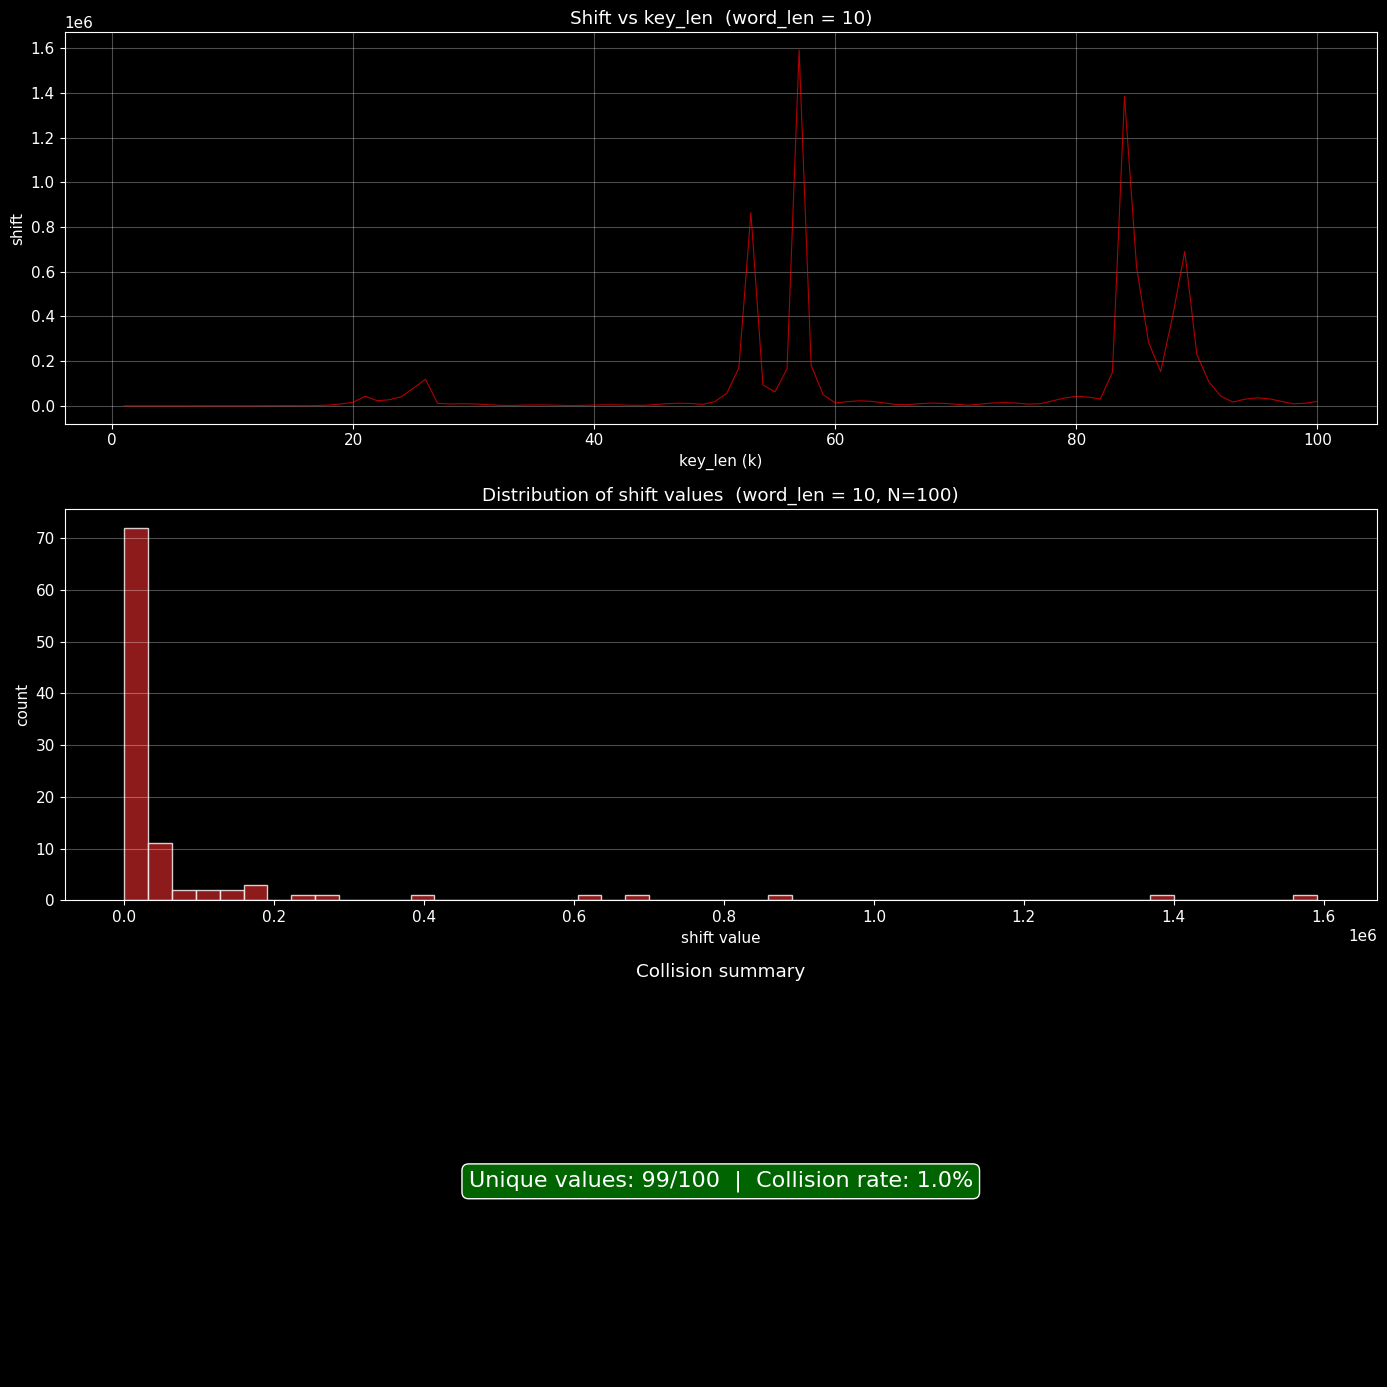

In [55]:
w_fixed = 10
k_range = np.arange(1, 101)
shifts_k = [compute_shift(w_fixed, int(k)) for k in k_range]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))

ax1.plot(k_range, shifts_k, "r-", alpha=0.7, linewidth=0.8)
ax1.set_xlabel("key_len (k)")
ax1.set_ylabel("shift")
ax1.set_title(f"Shift vs key_len  (word_len = {w_fixed})")
ax1.grid(True, alpha=0.3)

ax2.hist(shifts_k, bins=50, color="firebrick", edgecolor="white", alpha=0.8)
ax2.set_xlabel("shift value")
ax2.set_ylabel("count")
ax2.set_title(f"Distribution of shift values  (word_len = {w_fixed}, N={len(k_range)})")
ax2.grid(True, alpha=0.3, axis="y")

unique_k = len(set(shifts_k))
collision_rate_k = 1 - unique_k / len(shifts_k)

stats_text = (
  f"Unique values: {unique_k}/{len(shifts_k)}  |  Collision rate: {collision_rate_k:.1%}"
)
ax3.text(
  0.5,
  0.5,
  stats_text,
  transform=ax3.transAxes,
  fontsize=16,
  ha="center",
  va="center",
  bbox=dict(boxstyle="round", facecolor="darkgreen"),
)
ax3.set_title("Collision summary")
ax3.axis("off")

plt.tight_layout()
plt.show()

## 2. Two-Dimensional Heatmap

Sweep both variables over a dense grid and plot as a heatmap.
Colour intensity = shift magnitude.


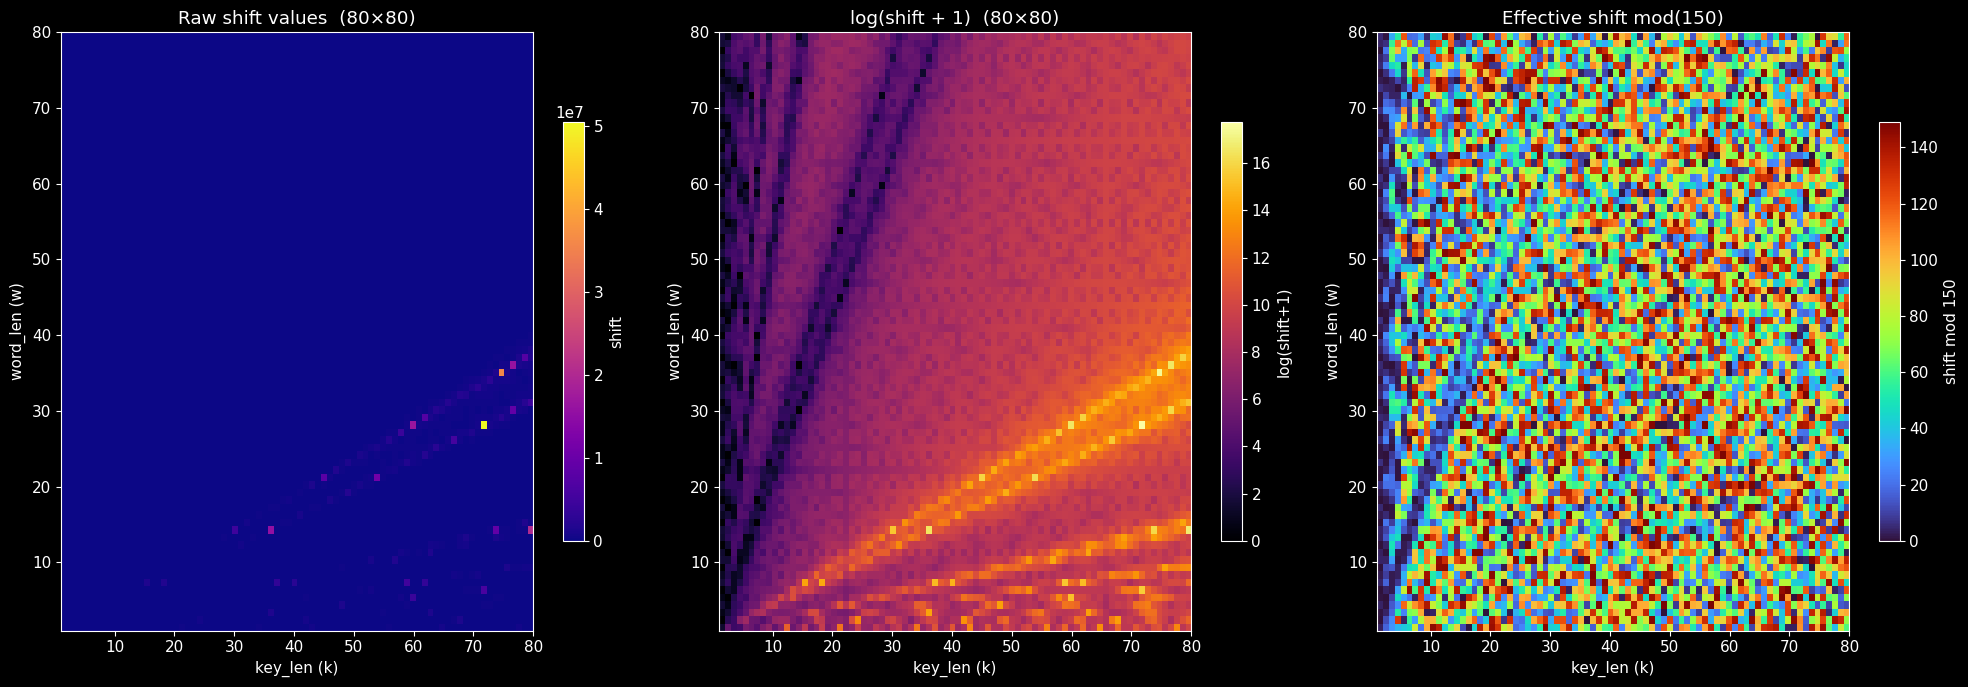

In [56]:
MAX_W = 80
MAX_K = 80

W = np.arange(1, MAX_W + 1)
K = np.arange(1, MAX_K + 1)
grid = np.zeros((MAX_W, MAX_K))

for i, w in enumerate(W):
  for j, k in enumerate(K):
    grid[i, j] = compute_shift(w, k)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Raw heatmap
im1 = axes[0].imshow(
  grid, origin="lower", aspect="auto", cmap="plasma", extent=[1, MAX_K, 1, MAX_W]
)
axes[0].set_xlabel("key_len (k)")
axes[0].set_ylabel("word_len (w)")
axes[0].set_title(f"Raw shift values  ({MAX_W}\u00d7{MAX_K})")
plt.colorbar(im1, ax=axes[0], label="shift", shrink=0.7)

# Log-scale for visibility of structure
log_grid = np.log1p(grid)
im2 = axes[1].imshow(
  log_grid, origin="lower", aspect="auto", cmap="inferno", extent=[1, MAX_K, 1, MAX_W]
)
axes[1].set_xlabel("key_len (k)")
axes[1].set_ylabel("word_len (w)")
axes[1].set_title(f"log(shift + 1)  ({MAX_W}\u00d7{MAX_K})")
plt.colorbar(im2, ax=axes[1], label="log(shift+1)", shrink=0.7)

# Collision map: same shift % len(alphabet) = same Caesar effect
alph_len = 150
eff_grid = grid % alph_len
im3 = axes[2].imshow(
  eff_grid,
  origin="lower",
  aspect="auto",
  cmap="turbo",
  extent=[1, MAX_K, 1, MAX_W],
  vmin=0,
  vmax=alph_len - 1,
)
axes[2].set_xlabel("key_len (k)")
axes[2].set_ylabel("word_len (w)")
axes[2].set_title(f"Effective shift mod({alph_len})")
plt.colorbar(im3, ax=axes[2], label="shift mod 150", shrink=0.7)

plt.tight_layout()
plt.show()

## 3. Global Distribution Analysis

Over the entire grid, what does the shift distribution look like?


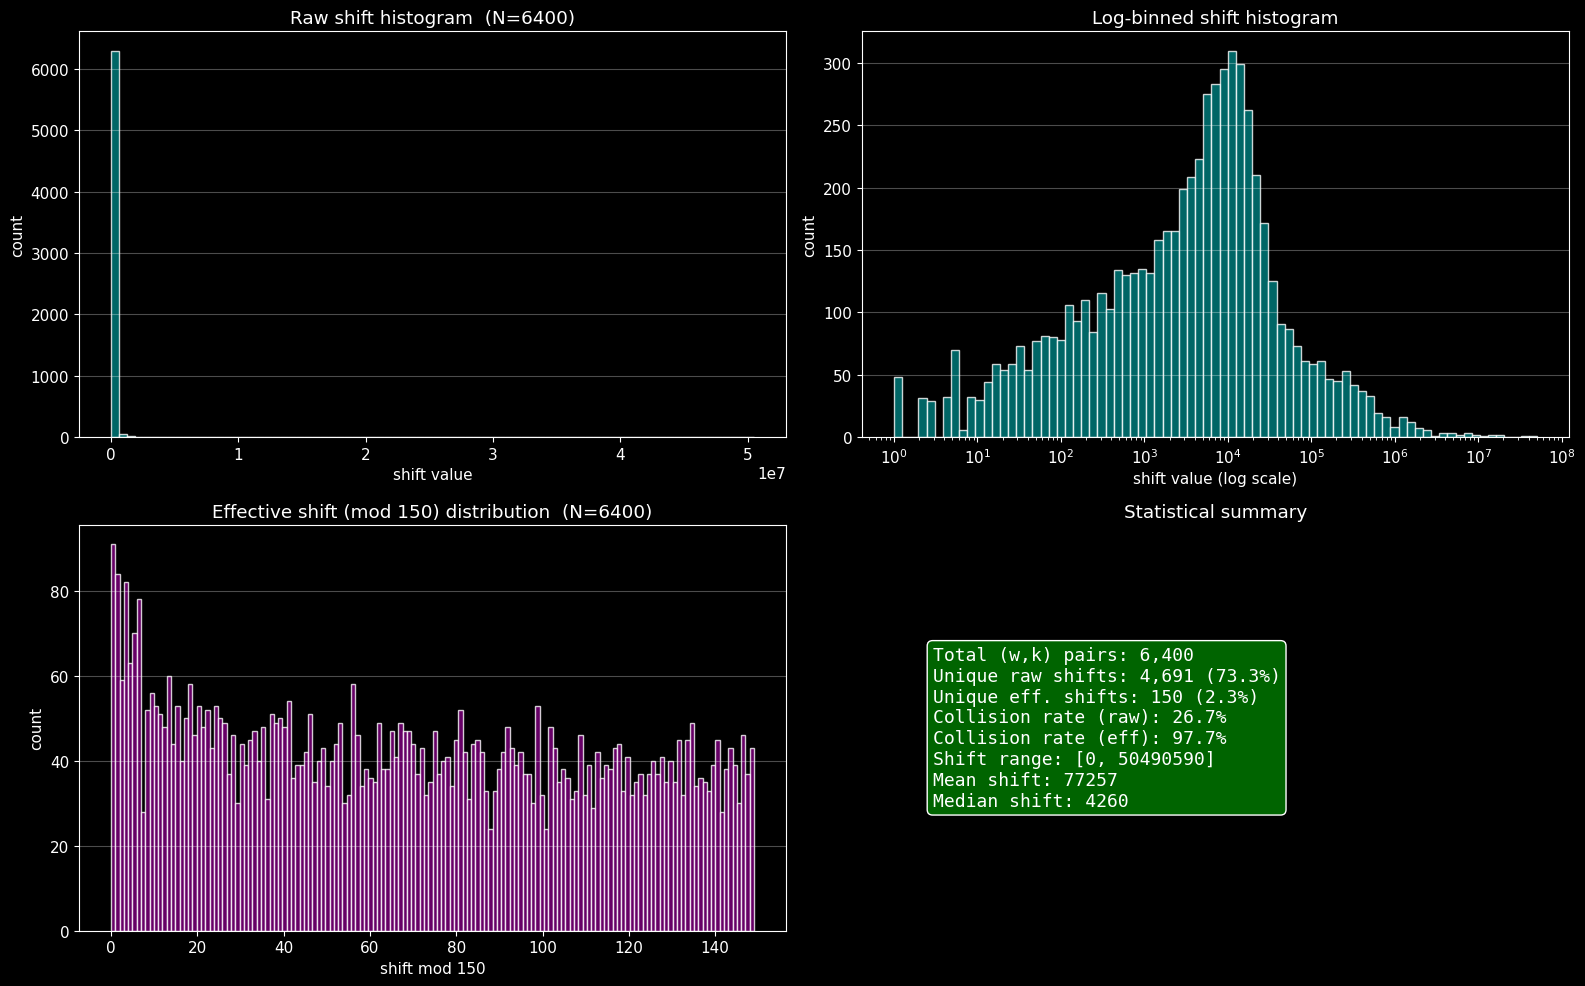

In [57]:
all_shifts = grid.flatten()
all_effective = all_shifts.astype(int) % 150

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw shift histogram
axes[0, 0].hist(all_shifts, bins=80, color="teal", edgecolor="white", alpha=0.8)
axes[0, 0].set_xlabel("shift value")
axes[0, 0].set_ylabel("count")
axes[0, 0].set_title(f"Raw shift histogram  (N={len(all_shifts)})")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Log-binned histogram (better for heavy-tailed distributions)
axes[0, 1].hist(
  all_shifts,
  bins=np.logspace(0, np.log10(max(all_shifts) + 1), 80),
  color="teal",
  edgecolor="white",
  alpha=0.8,
)
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("shift value (log scale)")
axes[0, 1].set_ylabel("count")
axes[0, 1].set_title("Log-binned shift histogram")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Effective shift histogram
axes[1, 0].hist(all_effective, bins=150, color="purple", edgecolor="white", alpha=0.8)
axes[1, 0].set_xlabel("shift mod 150")
axes[1, 0].set_ylabel("count")
axes[1, 0].set_title(f"Effective shift (mod 150) distribution  (N={len(all_effective)})")
axes[1, 0].grid(True, alpha=0.3, axis="y")

# Statistical summary
unique_total = len(set(all_shifts))
unique_eff = len(set(all_effective))
collision_total = 1 - unique_total / len(all_shifts)
collision_eff = 1 - unique_eff / len(all_effective)

summary = (
  f"Total (w,k) pairs: {len(all_shifts):,}\n"
  f"Unique raw shifts: {unique_total:,} ({unique_total / len(all_shifts):.1%})\n"
  f"Unique eff. shifts: {unique_eff:,} ({unique_eff / len(all_effective):.1%})\n"
  f"Collision rate (raw): {collision_total:.1%}\n"
  f"Collision rate (eff): {collision_eff:.1%}\n"
  f"Shift range: [{int(min(all_shifts))}, {int(max(all_shifts))}]\n"
  f"Mean shift: {all_shifts.mean():.0f}\n"
  f"Median shift: {np.median(all_shifts):.0f}"
)

axes[1, 1].text(
  0.1,
  0.5,
  summary,
  transform=axes[1, 1].transAxes,
  fontsize=13,
  va="center",
  fontfamily="monospace",
  bbox=dict(boxstyle="round", facecolor="darkgreen"),
)
axes[1, 1].set_title("Statistical summary")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## 4. Collision Deep-Dive

Which shift values are most repeated? How severe are the collisions?


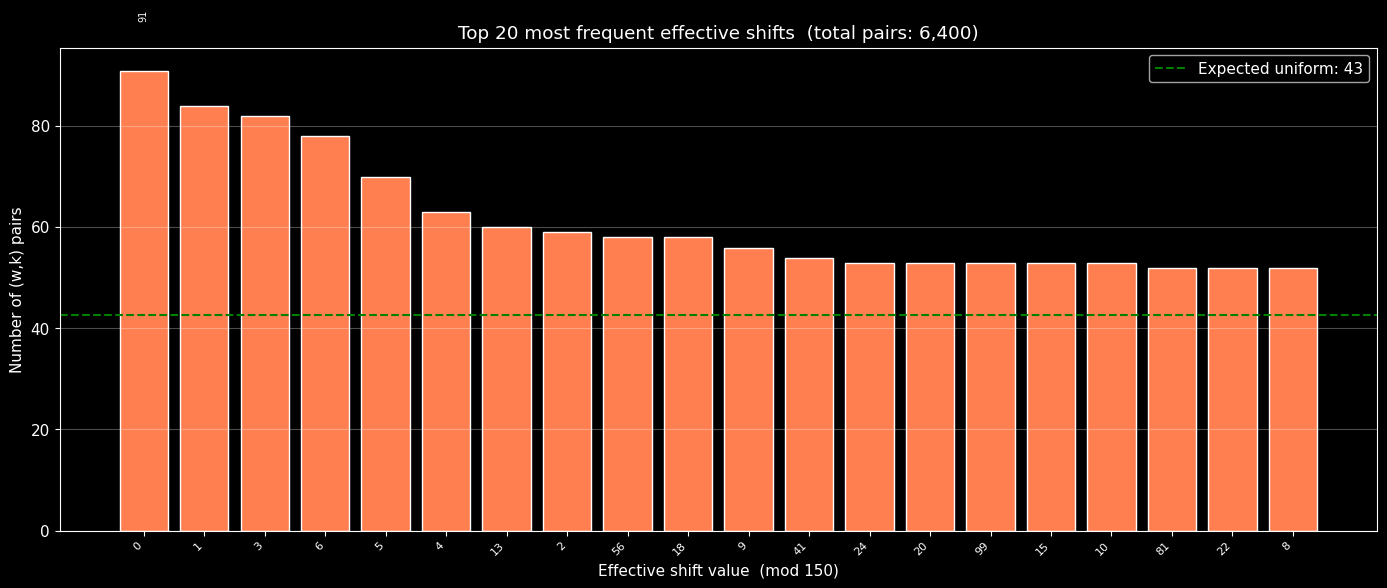


Pairs producing ZERO effective shift: 91 (1.42%)
Pairs producing shift 0 mod 150 (no encryption effect): WARNING if > 0


In [ ]:
counter_eff = Counter(all_effective)
top_collisions = counter_eff.most_common(20)

fig, ax = plt.subplots(figsize=(14, 6))

values, counts = zip(*top_collisions, strict=False)
bars = ax.bar(range(len(values)), counts, color="coral", edgecolor="white")
ax.set_xticks(range(len(values)))
ax.set_xticklabels(values, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Effective shift value  (mod 150)")
ax.set_ylabel("Number of (w,k) pairs")
ax.set_title(
  f"Top 20 most frequent effective shifts  (total pairs: {len(all_effective):,})"
)

expected = len(all_effective) / 150
ax.axhline(
  y=expected,
  color="green",
  linestyle="--",
  linewidth=1.5,
  label=f"Expected uniform: {expected:.0f}",
)

for bar, count, _ in zip(bars, counts, values, strict=False):
  if count > expected * 2:
    ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 10,
      f"{count}",
      ha="center",
      fontsize=7,
      rotation=90,
    )

ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Also report zero-effective-shift count (worst case: shift = 0 mod 150 = no encryption)
zero_count = counter_eff.get(0, 0)
print(
  f"\nPairs producing ZERO effective shift: {zero_count} ({zero_count / len(all_effective):.2%})"
)
print("Pairs producing shift 0 mod 150 (no encryption effect): WARNING if > 0")

## 5. Singularities and Edge Cases

The formula has potential division-by-zero or near-zero denominator issues
when $\sin(k/w + 1) \approx 0$ or $\cos(k/w - 1) \approx 0$.

We scan for these dangerous ratios.


In [59]:
def check_singularities(max_val=100):
  issues = []
  for w in range(1, max_val + 1):
    for k in range(1, max_val + 1):
      denom1 = sin(k / w + 1)
      denom2 = cos(k / w - 1)

      if abs(denom1) < 1e-6 or abs(denom2) < 1e-6:
        issues.append((w, k, denom1, denom2))

      # Check if shift computation fails
      try:
        compute_shift(w, k)
      except Exception as e:
        issues.append(("ERROR", w, k, str(e)))
  return issues


issues = check_singularities(100)
print(f"Dangerous (w,k) pairs found: {len(issues)}  (out of 10,000)")
for issue in issues[:10]:
  print(
    f"  w={issue[0]}, k={issue[1]}, sin_denom={issue[2]:.2e}, cos_denom={issue[3]:.2e}"
  )

Dangerous (w,k) pairs found: 0  (out of 10,000)


## 6. Auto-Correlation / Periodicity Check

Does the shift exhibit periodic behaviour with respect to word_len or key_len?


Strongest period (word_len sweep, lag>10): lag=12, corr=-0.155
Strongest period (key_len sweep, lag>10):   lag=63, corr=0.403


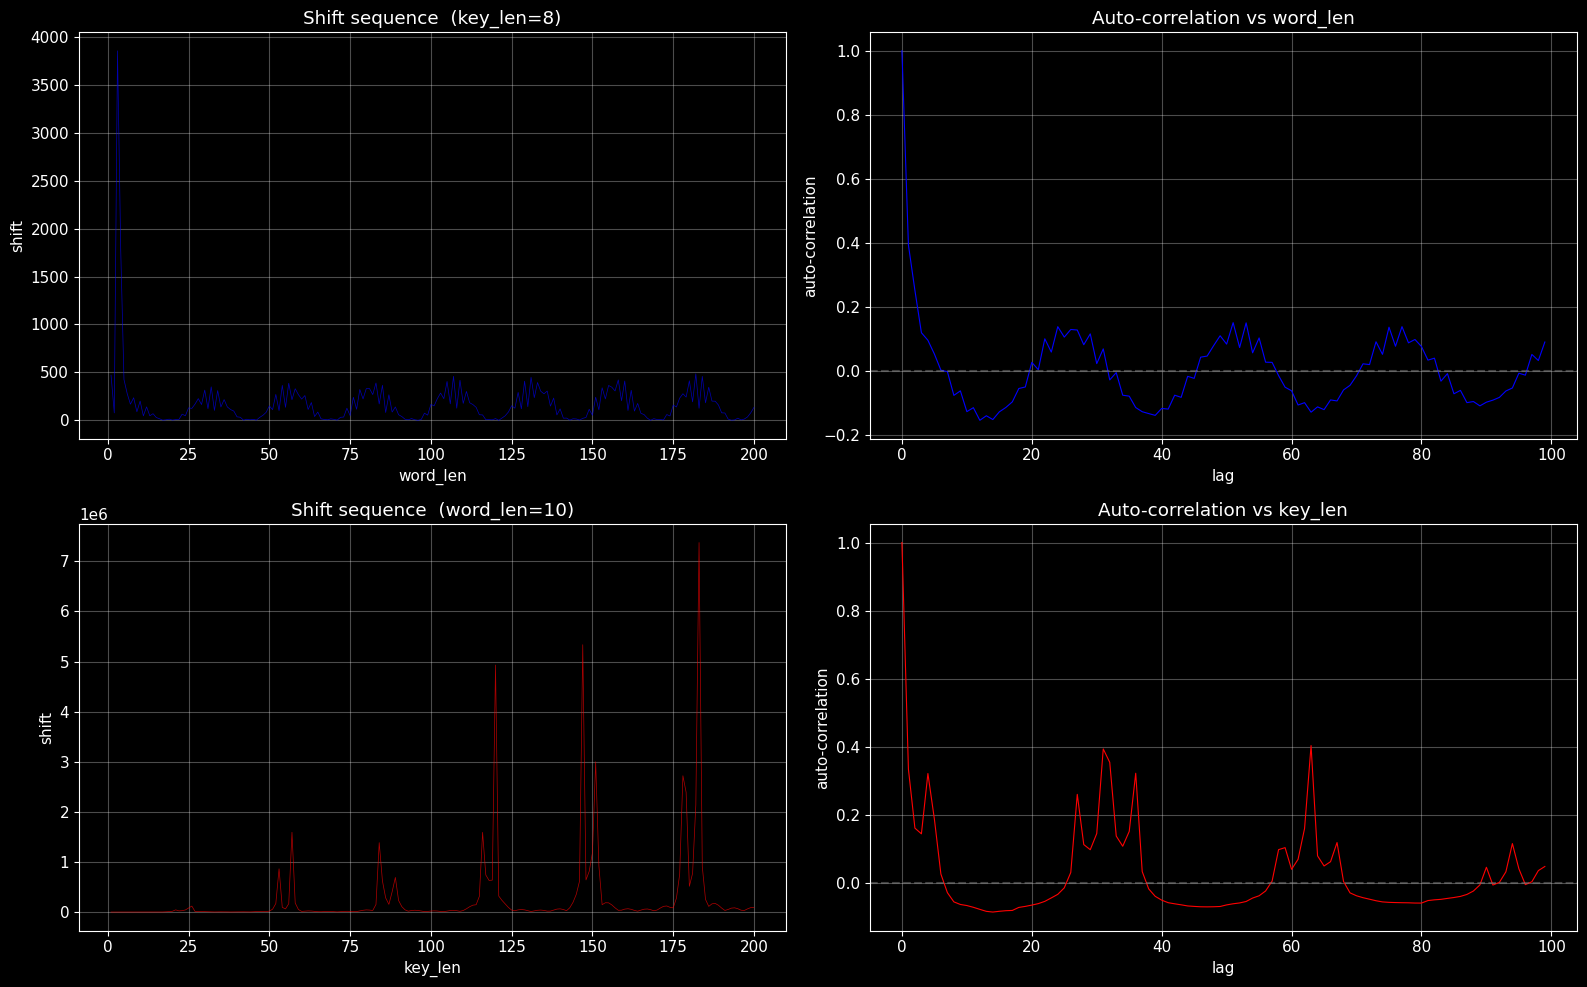

In [60]:
def auto_correlation(seq):
  """Compute auto-correlation of a 1D sequence."""
  seq = np.array(seq, dtype=float)
  seq -= seq.mean()
  result = np.correlate(seq, seq, mode="full")
  return result[result.size // 2 :] / result[result.size // 2]


# Sweep over word_len with fixed key_len
fixed_k = 8
w_seq = np.arange(1, 201)
shifts_seq_w = [compute_shift(int(w), fixed_k) for w in w_seq]
ac_w = auto_correlation(shifts_seq_w)

# Sweep over key_len with fixed word_len
fixed_w = 10
k_seq = np.arange(1, 201)
shifts_seq_k = [compute_shift(fixed_w, int(k)) for k in k_seq]
ac_k = auto_correlation(shifts_seq_k)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(w_seq, shifts_seq_w, "b-", linewidth=0.5, alpha=0.7)
axes[0, 0].set_xlabel("word_len")
axes[0, 0].set_ylabel("shift")
axes[0, 0].set_title(f"Shift sequence  (key_len={fixed_k})")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(ac_w[:100], "b-", linewidth=0.8)
axes[0, 1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0, 1].set_xlabel("lag")
axes[0, 1].set_ylabel("auto-correlation")
axes[0, 1].set_title("Auto-correlation vs word_len")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(k_seq, shifts_seq_k, "r-", linewidth=0.5, alpha=0.7)
axes[1, 0].set_xlabel("key_len")
axes[1, 0].set_ylabel("shift")
axes[1, 0].set_title(f"Shift sequence  (word_len={fixed_w})")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ac_k[:100], "r-", linewidth=0.8)
axes[1, 1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1, 1].set_xlabel("lag")
axes[1, 1].set_ylabel("auto-correlation")
axes[1, 1].set_title("Auto-correlation vs key_len")
axes[1, 1].grid(True, alpha=0.3)

# Check for significant periodicities
peak_idx_w = np.argmax(np.abs(ac_w[10:])) + 10
peak_idx_k = np.argmax(np.abs(ac_k[10:])) + 10
print(
  f"Strongest period (word_len sweep, lag>10): lag={peak_idx_w}, corr={ac_w[peak_idx_w]:.3f}"
)
print(
  f"Strongest period (key_len sweep, lag>10):   lag={peak_idx_k}, corr={ac_k[peak_idx_k]:.3f}"
)

plt.tight_layout()
plt.show()

## 7. Entropy / Quality Score

Treat the effective shift (mod alphabet length) as a discrete random variable
and compute its Shannon entropy. Maximum entropy = uniform distribution.


In [ ]:
def shannon_entropy(counter, total):
  """Compute Shannon entropy from a Counter."""
  entropy = 0.0
  for count in counter.values():
    p = count / total
    if p > 0:
      entropy -= p * np.log2(p)
  return entropy


# Compute entropies for different grid sizes
results = []
for size in [20, 40, 60, 80, 100]:
  grid_small = np.zeros((size, size))
  for i in range(size):
    for j in range(size):
      grid_small[i, j] = compute_shift(i + 1, j + 1)

  eff = grid_small.flatten().astype(int) % 150
  counter = Counter(eff)
  entropy = shannon_entropy(counter, len(eff))
  max_entropy = np.log2(150)  # uniform over 150 values
  unique_count = len(counter)

  results.append(
    {
      "grid": f"{size}x{size}",
      "pairs": len(eff),
      "entropy": entropy,
      "max_entropy": max_entropy,
      "ratio": entropy / max_entropy,
      "unique_vals": unique_count,
    }
  )

print(
  f"{'Grid':>10}  {'Pairs':>7}  {'Entropy':>9}  {'MaxEnt':>9}  {'Ratio':>7}  {'Unique':>7}"
)
print("-" * 55)
for r in results:
  print(
    f"{r['grid']:>10}  {r['pairs']:>7}  {r['entropy']:>9.4f}  {r['max_entropy']:>9.4f}  "
    f"{r['ratio']:>7.2%}  {r['unique_vals']:>7}"
  )

print(f"\nAlphabet size: 150  |  log2(150) = {np.log2(150):.4f} bits (theoretical max)")

      Grid    Pairs    Entropy     MaxEnt    Ratio   Unique
-------------------------------------------------------
     20x20      400     6.7603     7.2288   93.52%      136
     40x40     1600     7.0917     7.2288   98.10%      150
     60x60     3600     7.1539     7.2288   98.96%      150
     80x80     6400     7.1894     7.2288   99.45%      150
   100x100    10000     7.2016     7.2288   99.62%      150

Alphabet size: 150  |  log2(150) = 7.2288 bits (theoretical max)


## 8. Special Case: w = k (Equal Lengths)

When word length equals key length, the formula simplifies:

$$\frac{w}{k} = 1, \quad \frac{k}{w} = 1$$

$$C = |k \cdot \sin(k^2)| + k$$
$$S = \left| \mathrm{round}\left( C^2 \cdot \frac{\cos(0)}{\sin(2)} \cdot \frac{\sin(2)}{\cos(0)} \right) \right| = \left| \mathrm{round}(C^2) \right|$$

So $S = \lfloor C^2 + 0.5 \rfloor$. This path has **no trig interaction** between w and k.


Max difference between simplified and full formula: 0
Confirmed: they are identical on the diagonal


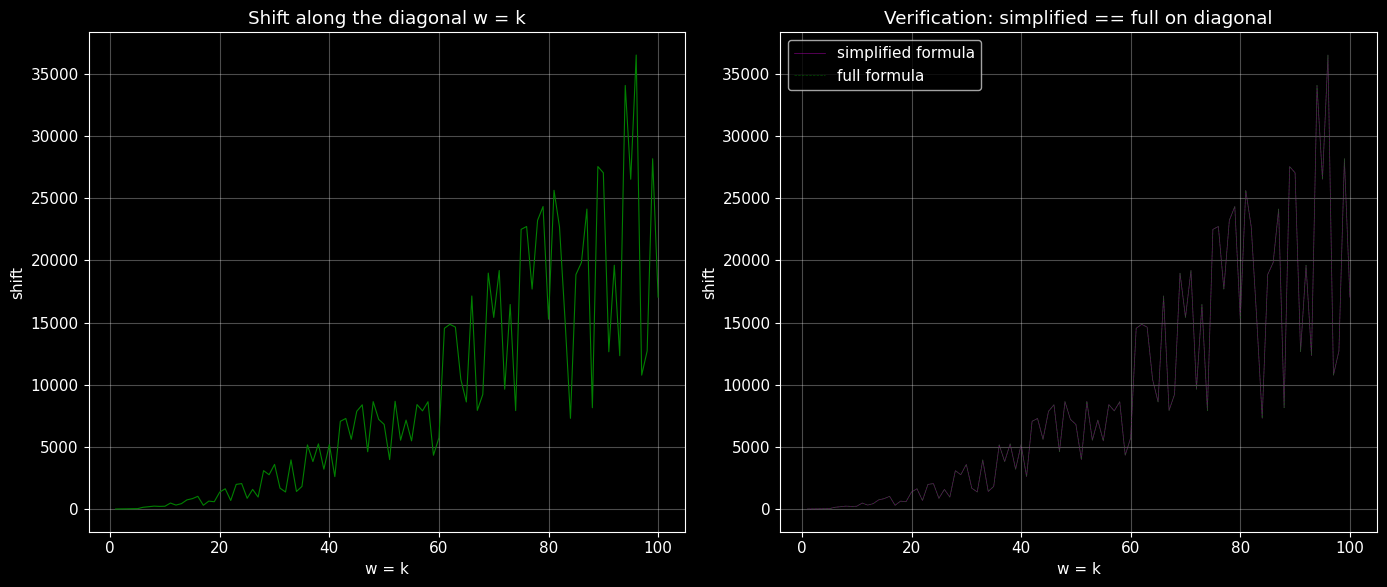

In [62]:
diag_range = np.arange(1, 101)
diag_shifts = [compute_shift(int(n), int(n)) for n in diag_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(diag_range, diag_shifts, "g-", linewidth=0.8)
ax1.set_xlabel("w = k")
ax1.set_ylabel("shift")
ax1.set_title("Shift along the diagonal w = k")
ax1.grid(True, alpha=0.3)

# Also compute what it would be without trig: |round((k*|sin(k²)|+k)²)|
simple_shifts = [abs(round((abs(k * sin(k * k)) + k) ** 2)) for k in diag_range]
ax2.plot(
  diag_range, simple_shifts, "m-", linewidth=0.5, alpha=0.6, label="simplified formula"
)
ax2.plot(diag_range, diag_shifts, "g--", linewidth=0.5, alpha=0.6, label="full formula")
ax2.set_xlabel("w = k")
ax2.set_ylabel("shift")
ax2.set_title("Verification: simplified == full on diagonal")
ax2.legend()
ax2.grid(True, alpha=0.3)

# They should be identical (or differ by at most 1 due to float rounding)
diffs = np.abs(np.array(diag_shifts) - np.array(simple_shifts))
max_diff = diffs.max()
print(f"Max difference between simplified and full formula: {max_diff}")
print(
  f"Confirmed: they are {'identical' if max_diff <= 1 else 'DIFFERENT'} on the diagonal"
)

plt.tight_layout()
plt.show()

## 9. Sensitivity to Small Changes

How much does the shift change when word_len or key_len changes by ±1?
Good crypto should have an "avalanche effect" — small input change → large output change.


Avalanche Analysis:
  word_len +1:  mean diff = 69806  median = 773  max = 16463169
  key_len +1:   mean diff = 58163  median = 766  max = 16230667
  Zero-change cases (word_len+1):  18 (0.51%)
  Zero-change cases (key_len+1):   11 (0.31%)


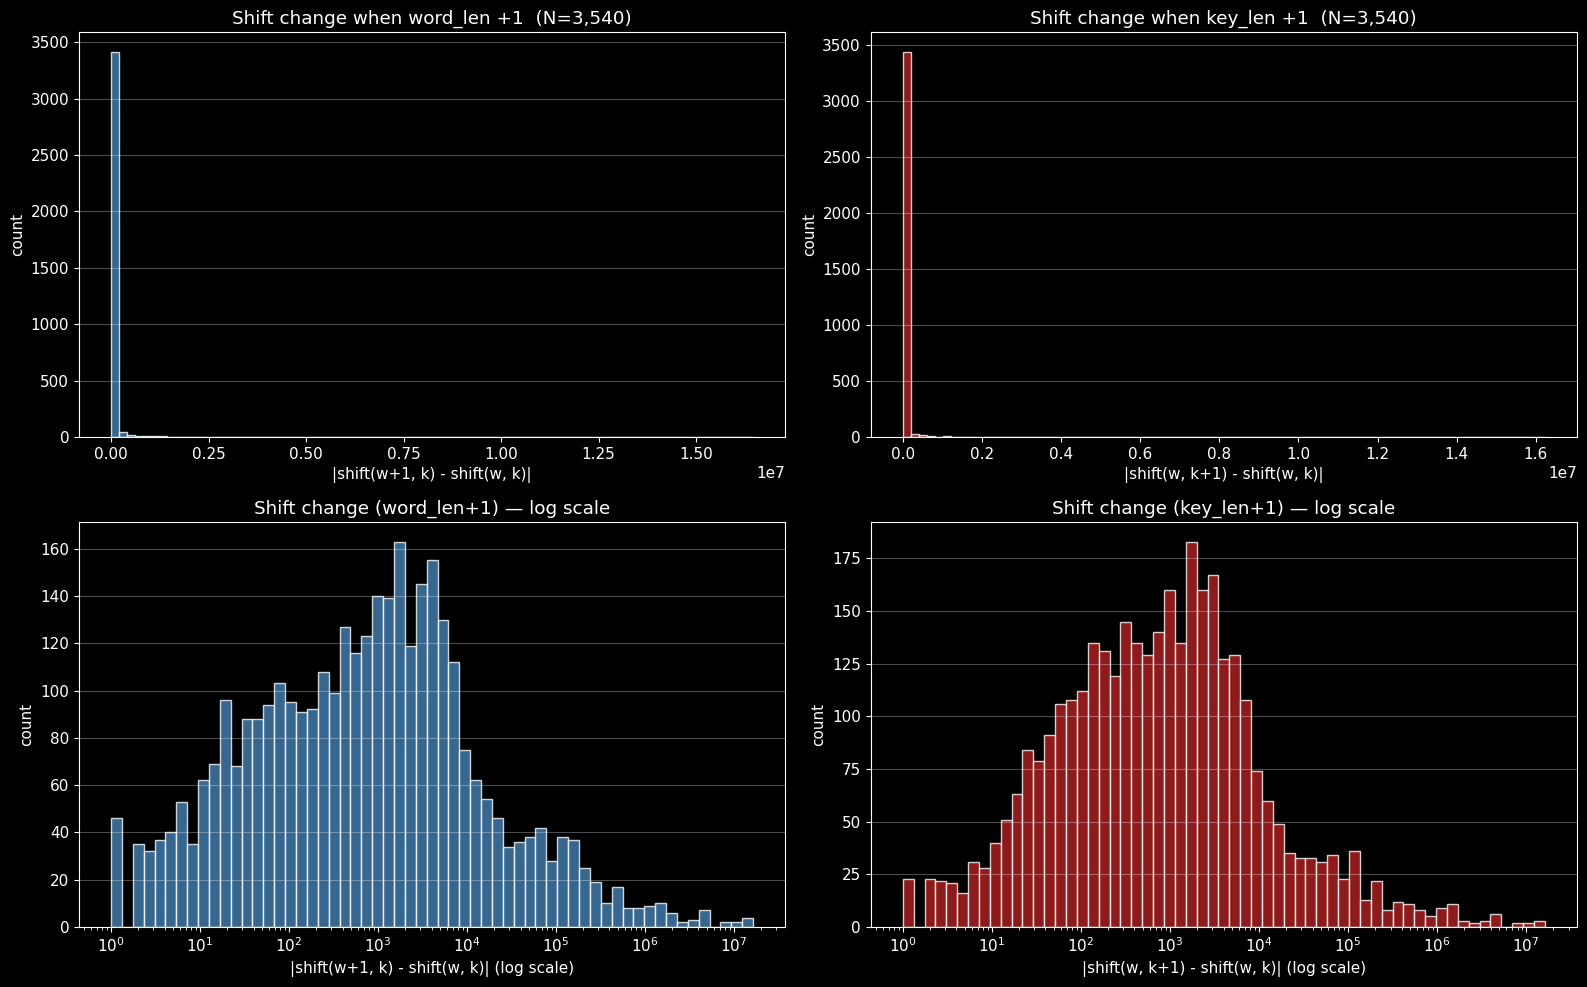

In [63]:
def avalanche_analysis(grid_size=100):
  """Compute shift change when w or k increments by 1."""
  w_diffs = []
  k_diffs = []

  for w in range(1, grid_size):
    for k in range(1, grid_size + 1):
      s1 = compute_shift(w, k)
      s2 = compute_shift(w + 1, k)
      w_diffs.append(abs(s2 - s1))

  for w in range(1, grid_size + 1):
    for k in range(1, grid_size):
      s1 = compute_shift(w, k)
      s2 = compute_shift(w, k + 1)
      k_diffs.append(abs(s2 - s1))

  w_diffs = np.array(w_diffs)
  k_diffs = np.array(k_diffs)

  return w_diffs, k_diffs


w_diffs, k_diffs = avalanche_analysis(60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(w_diffs, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0, 0].set_xlabel("|shift(w+1, k) - shift(w, k)|")
axes[0, 0].set_ylabel("count")
axes[0, 0].set_title(f"Shift change when word_len +1  (N={len(w_diffs):,})")
axes[0, 0].grid(True, alpha=0.3, axis="y")

axes[0, 1].hist(k_diffs, bins=80, color="firebrick", edgecolor="white", alpha=0.8)
axes[0, 1].set_xlabel("|shift(w, k+1) - shift(w, k)|")
axes[0, 1].set_ylabel("count")
axes[0, 1].set_title(f"Shift change when key_len +1  (N={len(k_diffs):,})")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Log-scale view
axes[1, 0].hist(
  w_diffs[w_diffs > 0],
  bins=np.logspace(0, np.log10(max(w_diffs) + 1), 60),
  color="steelblue",
  edgecolor="white",
  alpha=0.8,
)
axes[1, 0].set_xscale("log")
axes[1, 0].set_xlabel("|shift(w+1, k) - shift(w, k)| (log scale)")
axes[1, 0].set_ylabel("count")
axes[1, 0].set_title("Shift change (word_len+1) — log scale")
axes[1, 0].grid(True, alpha=0.3, axis="y")

axes[1, 1].hist(
  k_diffs[k_diffs > 0],
  bins=np.logspace(0, np.log10(max(k_diffs) + 1), 60),
  color="firebrick",
  edgecolor="white",
  alpha=0.8,
)
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("|shift(w, k+1) - shift(w, k)| (log scale)")
axes[1, 1].set_ylabel("count")
axes[1, 1].set_title("Shift change (key_len+1) — log scale")
axes[1, 1].grid(True, alpha=0.3, axis="y")

print("Avalanche Analysis:")
print(
  f"  word_len +1:  mean diff = {w_diffs.mean():.0f}  median = {np.median(w_diffs):.0f}  max = {w_diffs.max():.0f}"
)
print(
  f"  key_len +1:   mean diff = {k_diffs.mean():.0f}  median = {np.median(k_diffs):.0f}  max = {k_diffs.max():.0f}"
)
print(
  f"  Zero-change cases (word_len+1):  {(w_diffs == 0).sum()} ({100 * (w_diffs == 0).sum() / len(w_diffs):.2f}%)"
)
print(
  f"  Zero-change cases (key_len+1):   {(k_diffs == 0).sum()} ({100 * (k_diffs == 0).sum() / len(k_diffs):.2f}%)"
)

plt.tight_layout()
plt.show()

## 10. Summary and Recommendations

### Key findings

- **Collision rate**: how many (w,k) pairs map to the same effective shift (mod 150)?
- **Distribution uniformity**: how close to uniform is the effective shift?
- **Entropy ratio** (actual / theoretical max): quality of pseudorandomness
- **Singularities**: are there dangerous (w,k) ratios?
- **Avalanche effect**: small input change → large output change?
- **Periodicity**: is there repeating structure?
- **Zero-shift risk**: how often does shift mod 150 = 0 (no encryption)?

### Strengths of the current formula

- Produces a wide range of shift values (0 to hundreds of thousands)
- Trig functions introduce non-linearity
- Multiplication of trig ratios adds complexity

### Weaknesses

- **Float precision**: different platforms (x86 vs ARM / phone) may produce
  different results for the same input due to floating-point differences.
  This is a **critical bug** for cross-platform password sync.
- **Modular collapse**: all shifts ultimately reduce to shift mod 150,
  destroying most of the complexity.
- **Deterministic + key-based**: shift depends ONLY on lengths (w,k), not on
  actual content. All words of same length get the same shift with the same key.
- **No key stretching or salting**: the key string length determines behaviour
  identically regardless of key content ("abc" and "xyz" produce the same
  shift for same-length words).
- **Diagonal w=k collapses**: the trig ratio becomes 1, shift = |round(coef²)|.
- **sin/cos periodicities**: can create unexpected patterns.

### Recommendations for the password vault project

1. **Replace float trig with integer math** — use integer hash functions
   to avoid cross-platform non-determinism.
2. **Derive shift from key content, not just its length** — hash the actual
   key bytes (SHA-256 truncated) to drive the shift.
3. **Add salt** — a random per-vault value to ensure same passwords with
   same master key produce different ciphertexts.
4. **Multiple rounds** — apply the cipher 3–10 times with different subkeys
   to increase diffusion.
5. **Consider standard crypto** — for actually secure password storage,
   use AES-256-GCM + Argon2id key derivation.
